In [1]:
# Импорт библиотек
import requests
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
df=pd.read_csv("data_rdkit.csv")
df

,Smiles,pIC50,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,MinPartialCharge,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Br.CC(C)(NCc1cc([N+](=O)[O-])cc2nc(O)c(O)nc12)...,6.537602,11.108063,0.000000,-1.274467,0.428402,11.083333,403.189,0.322823,-0.489433,...,0,0,0,0,0,0,0,0,0,0
1,Br.CC(C)OC(=O)CN1Cc2cc(OCCCC(=O)N(C)C3CCCCC3)c...,7.200659,12.467464,0.000000,-0.336235,0.387809,15.878788,525.488,0.325413,-0.493572,...,0,0,0,0,0,0,0,0,0,0
2,Br.CC(OC(=O)CN1Cc2cc(OCCCC(=O)N(C)C3CCCCC3)ccc...,6.327902,12.522297,0.000000,-0.329360,0.335024,16.805556,567.569,0.325443,-0.493572,...,0,0,0,0,0,0,0,0,0,0
3,Br.CC(OC(=O)CN1Cc2cc(OCCCC(=O)N(C)C3CCCCC3)ccc...,8.096910,12.567656,0.000000,-0.367389,0.300234,15.947368,587.559,0.325763,-0.493572,...,0,0,0,0,0,0,0,0,0,0
4,Br.CC1CCCN(Cc2cc3nc(O)c(O)nc3cc2[N+](=O)[O-])C1,6.221849,11.350286,0.000000,-0.634812,0.602846,18.291667,399.245,0.275713,-0.489433,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12353,c1ccc2c(SCc3ccc(-c4ccc(-c5nnn[nH]5)cc4)cc3)ncn...,5.142668,4.451700,0.667748,0.667748,0.340455,11.034483,396.479,0.178904,-0.238828,...,0,1,0,0,0,1,0,0,0,0
12354,c1cnc2[nH]c3c(C4CC4)cccc3c2c1,5.455932,4.383724,0.774780,0.774780,0.650033,16.000000,208.264,0.137809,-0.338975,...,0,0,0,0,0,0,0,0,0,0
12355,c1cncc(-c2ccc3c(c2)C2(CCNCC2)CC3)c1,4.000000,4.248620,0.443256,0.443256,0.854420,20.000000,264.372,0.034583,-0.316667,...,0,0,0,0,0,0,0,0,0,0
12356,c1cncc(-c2cnc(NCc3cccc4c3CCO4)n3cnnc23)c1,5.585027,5.639178,0.665727,0.665727,0.613310,12.769231,344.378,0.209751,-0.492947,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.columns

Index(['Smiles', 'pIC50', 'MaxAbsEStateIndex', 'MinAbsEStateIndex',
       'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'MaxPartialCharge',
       'MinPartialCharge',
       ...
       'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone',
       'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=166)

In [4]:
df=df.dropna()
df

,Smiles,pIC50,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,MinPartialCharge,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Br.CC(C)(NCc1cc([N+](=O)[O-])cc2nc(O)c(O)nc12)...,6.537602,11.108063,0.000000,-1.274467,0.428402,11.083333,403.189,0.322823,-0.489433,...,0,0,0,0,0,0,0,0,0,0
1,Br.CC(C)OC(=O)CN1Cc2cc(OCCCC(=O)N(C)C3CCCCC3)c...,7.200659,12.467464,0.000000,-0.336235,0.387809,15.878788,525.488,0.325413,-0.493572,...,0,0,0,0,0,0,0,0,0,0
2,Br.CC(OC(=O)CN1Cc2cc(OCCCC(=O)N(C)C3CCCCC3)ccc...,6.327902,12.522297,0.000000,-0.329360,0.335024,16.805556,567.569,0.325443,-0.493572,...,0,0,0,0,0,0,0,0,0,0
3,Br.CC(OC(=O)CN1Cc2cc(OCCCC(=O)N(C)C3CCCCC3)ccc...,8.096910,12.567656,0.000000,-0.367389,0.300234,15.947368,587.559,0.325763,-0.493572,...,0,0,0,0,0,0,0,0,0,0
4,Br.CC1CCCN(Cc2cc3nc(O)c(O)nc3cc2[N+](=O)[O-])C1,6.221849,11.350286,0.000000,-0.634812,0.602846,18.291667,399.245,0.275713,-0.489433,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12353,c1ccc2c(SCc3ccc(-c4ccc(-c5nnn[nH]5)cc4)cc3)ncn...,5.142668,4.451700,0.667748,0.667748,0.340455,11.034483,396.479,0.178904,-0.238828,...,0,1,0,0,0,1,0,0,0,0
12354,c1cnc2[nH]c3c(C4CC4)cccc3c2c1,5.455932,4.383724,0.774780,0.774780,0.650033,16.000000,208.264,0.137809,-0.338975,...,0,0,0,0,0,0,0,0,0,0
12355,c1cncc(-c2ccc3c(c2)C2(CCNCC2)CC3)c1,4.000000,4.248620,0.443256,0.443256,0.854420,20.000000,264.372,0.034583,-0.316667,...,0,0,0,0,0,0,0,0,0,0
12356,c1cncc(-c2cnc(NCc3cccc4c3CCO4)n3cnnc23)c1,5.585027,5.639178,0.665727,0.665727,0.613310,12.769231,344.378,0.209751,-0.492947,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12358 entries, 0 to 12357
Columns: 166 entries, Smiles to fr_urea
dtypes: float64(78), int64(87), object(1)
memory usage: 15.7+ MB


In [6]:
df.describe()

,pIC50,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
count,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,...,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000,12358.000000
mean,6.322479,12.368329,0.122432,-1.445359,0.586908,17.007096,414.386003,0.300721,-0.443876,1.145483,...,0.000243,0.064978,0.033177,0.038518,0.001537,0.010520,0.022253,0.051465,0.086260,0.069024
std,1.458666,1.954606,0.142286,1.779555,0.194730,5.356792,133.413246,0.083267,0.073729,0.181409,...,0.015579,0.254573,0.186195,0.207426,0.039182,0.102028,0.149147,0.223863,0.516307,0.256046
min,1.000000,3.512138,0.000000,-6.164342,0.008202,9.166667,115.925000,-0.002020,-0.767748,0.160494,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.200659,12.071591,0.028014,-2.948318,0.474360,12.925926,343.774750,0.251445,-0.492870,1.032258,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.301030,12.887146,0.075489,-0.593022,0.604305,16.303030,405.447500,0.290425,-0.474581,1.147059,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.259637,13.424794,0.166064,-0.279001,0.726617,19.280000,461.507000,0.340528,-0.374178,1.264706,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11.198288,17.928541,1.209877,1.003102,0.947001,56.318182,3080.498000,0.585787,-0.222295,1.846154,...,1.000000,3.000000,3.000000,3.000000,1.000000,1.000000,2.000000,2.000000,12.000000,2.000000


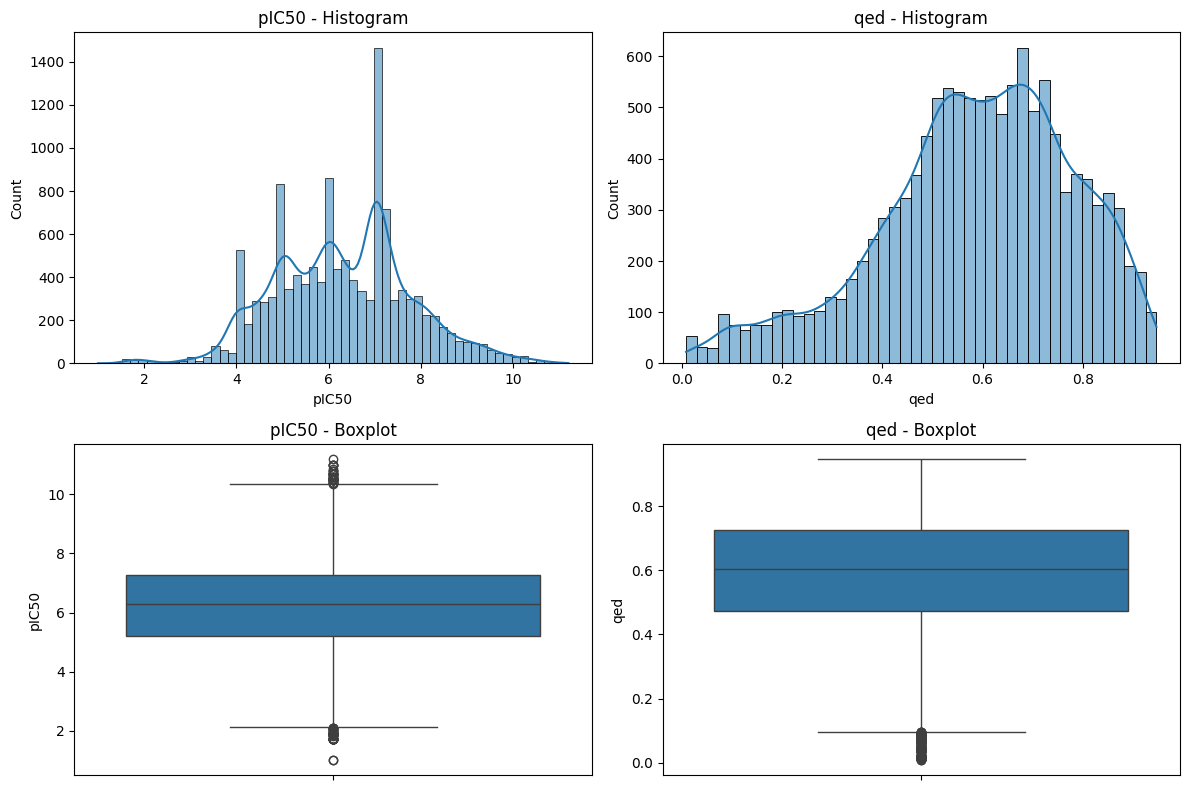

In [7]:
# распределение данных
features = ['pIC50', 'qed']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(features):
    # Гистограмма с KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'{col} - Histogram')

    # Boxplot
    sns.boxplot(data=df, y=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

In [8]:
# Функция для определения выбросов по IQR
def is_outlier(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

In [9]:
# Добавляем колонки-индикаторы
df['pIC50_outlier'] = is_outlier(df['pIC50'])
df['QED_outlier'] = is_outlier(df['qed'])

# Создаём датасет с выбросами по pIC50
df_pIC50_outliers = df[df['pIC50_outlier']].copy()

# Создаём датасет с выбросами по QED
df_QED_outliers = df[df['QED_outlier']].copy()

# Выбираем нужные колонки (если есть название молекулы — добавьте)
columns_to_keep = ['Smiles', 'pIC50', 'qed']  # можно добавить другие колонки

# Применяем выборку колонок
df_pIC50_outliers = df_pIC50_outliers[columns_to_keep]
df_QED_outliers = df_QED_outliers[columns_to_keep]

# Выводим информацию
print(f"Выбросы по pIC50: {len(df_pIC50_outliers)} молекул")
print(f"Выбросы по QED: {len(df_QED_outliers)} молекул")

# Сохраняем в CSV файлы
df_pIC50_outliers.to_csv('outliers_pIC50.csv', index=False)
df_QED_outliers.to_csv('outliers_QED.csv', index=False)

print("\nФайлы сохранены:")
print("  - outliers_pIC50.csv")
print("  - outliers_QED.csv")

Выбросы по pIC50: 99 молекул
Выбросы по QED: 220 молекул

Файлы сохранены:
  - outliers_pIC50.csv
  - outliers_QED.csv


In [16]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 2.4 MB/s eta 0:00:42
    --------------------------------------- 1.3/100.2 MB 2.4 MB/s eta 0:00:42
    --------------------------------------- 1.8/100.2 MB 2.4 MB/s eta 0:00:42
    --------------------------------------- 2.4/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 2.9/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.4/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.9/100.2 MB 2.4 MB/s eta 0:00:40
   - -------------------------------------- 4.2/100.2 MB 2.4 MB/s eta 0:00:40
   - -------------------------------------- 4.7/100.2 MB 2.4 MB/s eta 0:00:40
   -- ------------------------------------- 5.2/100.2 MB 2.4 MB/s eta 0:00:40
   -- ------------------------------------- 5.8/100.2 MB 2.4 MB/s eta 0:00:40



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from catboost import CatBoostRegressor


X = df.drop(columns=['Smiles', 'pIC50']).values
y = df['pIC50'].values

# 3. Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = CatBoostRegressor().fit(X_train,y_train)


Learning rate set to 0.058802
0:	learn: 1.4401247	total: 149ms	remaining: 2m 28s
1:	learn: 1.4178731	total: 155ms	remaining: 1m 17s
2:	learn: 1.3988732	total: 162ms	remaining: 54s
3:	learn: 1.3791343	total: 169ms	remaining: 42.2s
4:	learn: 1.3622687	total: 176ms	remaining: 35.1s
5:	learn: 1.3462876	total: 183ms	remaining: 30.4s
6:	learn: 1.3320246	total: 190ms	remaining: 26.9s
7:	learn: 1.3183012	total: 196ms	remaining: 24.3s
8:	learn: 1.3062915	total: 203ms	remaining: 22.3s
9:	learn: 1.2939621	total: 211ms	remaining: 20.9s
10:	learn: 1.2824004	total: 217ms	remaining: 19.5s
11:	learn: 1.2717115	total: 224ms	remaining: 18.4s
12:	learn: 1.2566315	total: 230ms	remaining: 17.5s
13:	learn: 1.2468440	total: 236ms	remaining: 16.6s
14:	learn: 1.2361928	total: 242ms	remaining: 15.9s
15:	learn: 1.2274078	total: 248ms	remaining: 15.2s
16:	learn: 1.2182883	total: 254ms	remaining: 14.7s
17:	learn: 1.2095898	total: 260ms	remaining: 14.2s
18:	learn: 1.2024648	total: 266ms	remaining: 13.7s
19:	learn: 

In [22]:
cat_predict = model.predict(X_test)

In [23]:
print(r2_score(y_pred)

SyntaxError: incomplete input (336521185.py, line 1)

In [25]:
r2 = r2_score(y_test, cat_predict)
r2

0.7544207637540352

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Подготовка данных
X = df.drop(columns=['Smiles', 'pIC50']).values
y = df['pIC50'].values

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# Создание модели с метрикой R2
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    eval_metric='R2',
    verbose=100,
    random_seed=42
)

# Обучение
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=True  # показывает график обучения
)

# Предсказание и оценка
y_pred = model.predict(X_test)

# Метрики
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R2 Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

# Важность признаков
feature_importance = model.get_feature_importance()
feature_names = df.drop(columns=['Smiles', 'pIC50']).columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
print("\nВажность признаков:")
print(importance_df)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.0504226	test: 0.0469084	best: 0.0469084 (0)	total: 7.09ms	remaining: 7.09s
100:	learn: 0.6727845	test: 0.6245835	best: 0.6245835 (100)	total: 673ms	remaining: 5.99s
200:	learn: 0.7752355	test: 0.6944743	best: 0.6944743 (200)	total: 1.35s	remaining: 5.37s
300:	learn: 0.8264463	test: 0.7228470	best: 0.7228470 (300)	total: 2.02s	remaining: 4.7s
400:	learn: 0.8569796	test: 0.7375539	best: 0.7375539 (400)	total: 2.69s	remaining: 4.02s
500:	learn: 0.8789267	test: 0.7473856	best: 0.7473856 (500)	total: 3.38s	remaining: 3.37s
600:	learn: 0.8963486	test: 0.7547269	best: 0.7547269 (600)	total: 4.07s	remaining: 2.7s
700:	learn: 0.9095330	test: 0.7591592	best: 0.7591592 (700)	total: 4.75s	remaining: 2.03s
800:	learn: 0.9206641	test: 0.7630603	best: 0.7631742 (798)	total: 5.48s	remaining: 1.36s
900:	learn: 0.9292082	test: 0.7657058	best: 0.7657058 (900)	total: 6.18s	remaining: 680ms
999:	learn: 0.9363266	test: 0.7677938	best: 0.7677938 (999)	total: 6.83s	remaining: 0us

bestTest = 0.767

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
import numpy as np

# Подготовка данных
X = df.drop(columns=['Smiles', 'pIC50']).values
y = df['pIC50'].values

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Создание модели с метрикой R2
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    eval_metric='R2',
    verbose=100,
    random_seed=42
)

# ============= КРОСС-ВАЛИДАЦИЯ =============

print("=" * 50)
print("КРОСС-ВАЛИДАЦИЯ")
print("=" * 50)

# Способ 1: Простая кросс-валидация с cross_val_score
cv_scores_r2 = cross_val_score(
    model, X_train, y_train, 
    cv=5,  # 5-кратная кросс-валидация
    scoring='r2',
    verbose=0
)

# Для RMSE нужно создать свой scorer
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

cv_scores_rmse = cross_val_score(
    model, X_train, y_train,
    cv=5,
    scoring=rmse_scorer,
    verbose=0
)
# Преобразуем отрицательные значения обратно в положительные
cv_scores_rmse = -cv_scores_rmse

print(f"R2 - 5-fold CV:")
print(f"  Среднее: {cv_scores_r2.mean():.4f}")
print(f"  Стандартное отклонение: {cv_scores_r2.std():.4f}")
print(f"  Минимум: {cv_scores_r2.min():.4f}")
print(f"  Максимум: {cv_scores_r2.max():.4f}")
print(f"  Все значения: {cv_scores_r2}")

print(f"\nRMSE - 5-fold CV:")
print(f"  Среднее: {cv_scores_rmse.mean():.4f}")
print(f"  Стандартное отклонение: {cv_scores_rmse.std():.4f}")
print(f"  Минимум: {cv_scores_rmse.min():.4f}")
print(f"  Максимум: {cv_scores_rmse.max():.4f}")

# Способ 2: Более детальная кросс-валидация с KFold
print("\n" + "=" * 50)
print("ДЕТАЛЬНАЯ КРОСС-ВАЛИДАЦИЯ (с обучением на каждой фолде)")
print("=" * 50)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {
    'fold': [],
    'r2_train': [],
    'r2_val': [],
    'rmse_train': [],
    'rmse_val': []
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # Обучение модели на фолде
    model_fold = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        eval_metric='R2',
        verbose=False,  # отключаем вывод для чистоты
        random_seed=42
    )
    
    model_fold.fit(X_train_fold, y_train_fold)
    
    # Предсказания
    y_train_pred = model_fold.predict(X_train_fold)
    y_val_pred = model_fold.predict(X_val_fold)
    
    # Метрики
    r2_train = r2_score(y_train_fold, y_train_pred)
    r2_val = r2_score(y_val_fold, y_val_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train_fold, y_train_pred))
    rmse_val = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
    
    cv_results['fold'].append(fold)
    cv_results['r2_train'].append(r2_train)
    cv_results['r2_val'].append(r2_val)
    cv_results['rmse_train'].append(rmse_train)
    cv_results['rmse_val'].append(rmse_val)
    
    print(f"\nFold {fold}:")
    print(f"  Train - R2: {r2_train:.4f}, RMSE: {rmse_train:.4f}")
    print(f"  Val   - R2: {r2_val:.4f}, RMSE: {rmse_val:.4f}")
    print(f"  Overfitting gap: R2 diff = {r2_train - r2_val:.4f}")

# Сводка по кросс-валидации
print("\n" + "=" * 50)
print("СВОДКА КРОСС-ВАЛИДАЦИИ")
print("=" * 50)
print(f"Средний R2 на валидации: {np.mean(cv_results['r2_val']):.4f} (+/- {np.std(cv_results['r2_val']):.4f})")
print(f"Средний RMSE на валидации: {np.mean(cv_results['rmse_val']):.4f} (+/- {np.std(cv_results['rmse_val']):.4f})")
print(f"Средний overfitting gap (R2): {np.mean(np.array(cv_results['r2_train']) - np.array(cv_results['r2_val'])):.4f}")

# ============= ОБУЧЕНИЕ НА ВСЕХ ДАННЫХ =============

print("\n" + "=" * 50)
print("ОБУЧЕНИЕ НА ВСЕЙ ТРЕНИРОВОЧНОЙ ВЫБОРКЕ")
print("=" * 50)

# Обучение на всех тренировочных данных
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=100,
    plot=True
)

# Предсказание и оценка на тестовой выборке
y_pred = model.predict(X_test)

# Метрики
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nРезультаты на тестовой выборке:")
print(f'R2 Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

# Сравнение с кросс-валидацией
print("\n" + "=" * 50)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 50)
print(f"CV средний R2: {np.mean(cv_results['r2_val']):.4f}")
print(f"Test R2: {r2:.4f}")
print(f"Разница: {r2 - np.mean(cv_results['r2_val']):.4f}")

# Важность признаков
feature_importance = model.get_feature_importance()
feature_names = df.drop(columns=['Smiles', 'pIC50']).columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)
print("\nВажность признаков:")
print(importance_df)

# ============= ОПЦИОНАЛЬНО: КРОСС-ВАЛИДАЦИЯ С ПОДБОРОМ ПАРАМЕТРОВ =============

print("\n" + "=" * 50)
print("КРОСС-ВАЛИДАЦИЯ ДЛЯ ПОДБОРА ПАРАМЕТРОВ")
print("=" * 50)

# Пример подбора learning_rate с помощью кросс-валидации
learning_rates = [0.01, 0.05, 0.1, 0.2]
cv_results_params = []

for lr in learning_rates:
    model_temp = CatBoostRegressor(
        iterations=500,  # меньше итераций для скорости
        learning_rate=lr,
        depth=6,
        eval_metric='R2',
        verbose=False,
        random_seed=42
    )
    
    scores = cross_val_score(
        model_temp, X_train, y_train,
        cv=3,  # 3-кратная для скорости
        scoring='r2',
        verbose=0
    )
    
    cv_results_params.append({
        'learning_rate': lr,
        'mean_r2': scores.mean(),
        'std_r2': scores.std()
    })
    print(f"learning_rate={lr}: R2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Лучший параметр
best_lr = max(cv_results_params, key=lambda x: x['mean_r2'])
print(f"\nЛучший learning_rate: {best_lr['learning_rate']} со средним R2 = {best_lr['mean_r2']:.4f}")

КРОСС-ВАЛИДАЦИЯ
0:	learn: 0.0506830	total: 16.2ms	remaining: 16.1s
100:	learn: 0.6778317	total: 636ms	remaining: 5.66s
200:	learn: 0.7830990	total: 1.26s	remaining: 5.02s
300:	learn: 0.8376420	total: 1.88s	remaining: 4.38s
400:	learn: 0.8701149	total: 2.49s	remaining: 3.72s
500:	learn: 0.8921002	total: 3.1s	remaining: 3.09s
600:	learn: 0.9072981	total: 3.7s	remaining: 2.46s
700:	learn: 0.9190566	total: 4.3s	remaining: 1.83s
800:	learn: 0.9294976	total: 4.91s	remaining: 1.22s
900:	learn: 0.9381582	total: 5.52s	remaining: 606ms
999:	learn: 0.9452140	total: 6.12s	remaining: 0us
0:	learn: 0.0484224	total: 6.68ms	remaining: 6.67s
100:	learn: 0.6749959	total: 655ms	remaining: 5.83s
200:	learn: 0.7779359	total: 1.27s	remaining: 5.05s
300:	learn: 0.8319146	total: 1.89s	remaining: 4.38s
400:	learn: 0.8655239	total: 2.5s	remaining: 3.74s
500:	learn: 0.8910047	total: 3.13s	remaining: 3.11s
600:	learn: 0.9083604	total: 3.75s	remaining: 2.49s
700:	learn: 0.9204723	total: 4.36s	remaining: 1.86s
800:

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.0504226	test: 0.0469084	best: 0.0469084 (0)	total: 12.6ms	remaining: 12.6s
100:	learn: 0.6727845	test: 0.6245835	best: 0.6245835 (100)	total: 1.17s	remaining: 10.4s
200:	learn: 0.7752355	test: 0.6944743	best: 0.6944743 (200)	total: 2.28s	remaining: 9.07s
300:	learn: 0.8264463	test: 0.7228470	best: 0.7228470 (300)	total: 3.38s	remaining: 7.85s
400:	learn: 0.8569796	test: 0.7375539	best: 0.7375539 (400)	total: 4.47s	remaining: 6.67s
500:	learn: 0.8789267	test: 0.7473856	best: 0.7473856 (500)	total: 5.73s	remaining: 5.71s
600:	learn: 0.8963486	test: 0.7547269	best: 0.7547269 (600)	total: 6.93s	remaining: 4.6s
700:	learn: 0.9095330	test: 0.7591592	best: 0.7591592 (700)	total: 8.24s	remaining: 3.51s
800:	learn: 0.9206641	test: 0.7630603	best: 0.7631742 (798)	total: 9.5s	remaining: 2.36s
900:	learn: 0.9292082	test: 0.7657058	best: 0.7657058 (900)	total: 10.9s	remaining: 1.19s
999:	learn: 0.9363266	test: 0.7677938	best: 0.7677938 (999)	total: 12.1s	remaining: 0us

bestTest = 0.767